# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Import

In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
from functions import osc_set_standard, osc_check_standard, capture_trace, capture_trace_simple
from functions import snspd_dark_counts
from functions import snspd_counts_vs_wavelength
from functions import laser_set_standard, laser_get_standard
from functions import make_title
import snspd
params = snspd.snspd()

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260414-27028-qcodes.log
Experiment loaded. Last ID no: 475


# Instruments

In [3]:
station = Station(config_file="friesland.yaml")

# Light Counts

Text(0, 0.5, 'Count Rate (cps)')

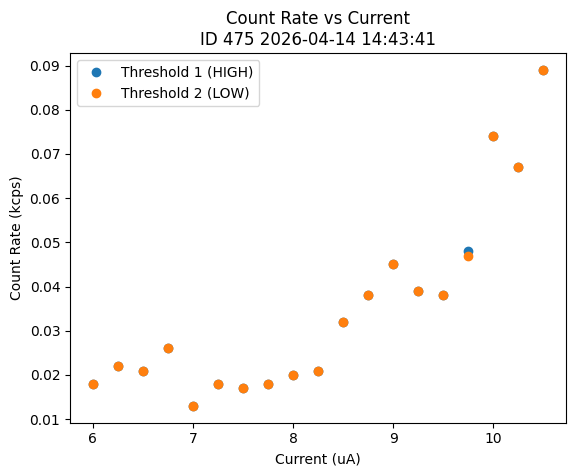

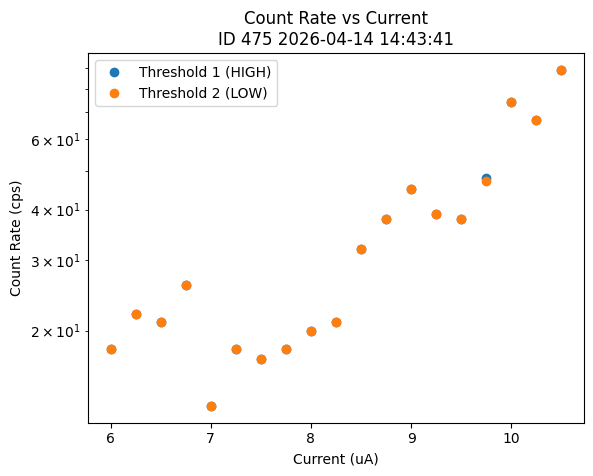

In [8]:
ID = 475
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][~np.isnan(data['yoko_current']['yoko_current'])]*1e6 # convert to uA
CR1 = data['CR1']['CR1'][~np.isnan(data['CR1']['CR1'])]
CR2 = data['CR2']['CR2'][~np.isnan(data['CR2']['CR2'])]
title = 'Count Rate vs Current'
ts = make_title(title, ID, extra=None)

plt.plot(current, CR1*1e-3, 'o', label='Threshold 1 (HIGH)')
plt.plot(current, CR2*1e-3, 'o', label='Threshold 2 (LOW)')
plt.title(ts)
plt.legend()
plt.xlabel(f'Current (uA)')
plt.ylabel('Count Rate (kcps)')

plt.figure()
plt.semilogy(current, CR1, 'o', label='Threshold 1 (HIGH)')
plt.semilogy(current, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(ts)
plt.legend()
plt.xlabel(f'Current (uA)')
plt.ylabel('Count Rate (cps)')

Text(0, 0.5, 'Count Rate (cps)')

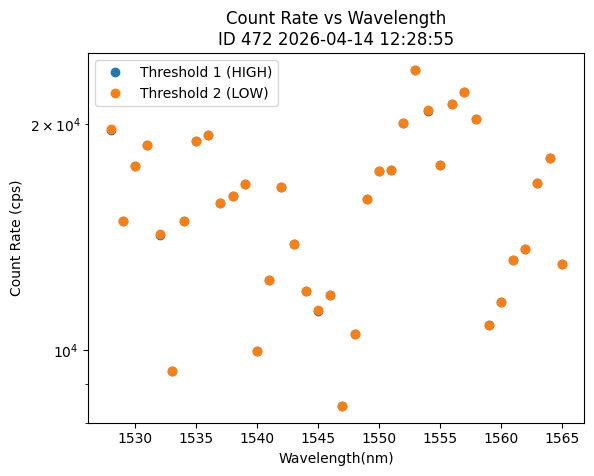

In [31]:
plt.semilogy(wavelength, CR1, 'o', label='Threshold 1 (HIGH)')
plt.semilogy(wavelength, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(ts)
plt.legend()
plt.xlabel(f'Wavelength(nm)')
plt.ylabel('Count Rate (cps)')

Result from Measurement 4-1 ID ... for comparison 

In [1]:
v_target = 5.3
ID = 464
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1'][0]
CR2 = data['CR2']['CR2'][0]
v_attenuator = data['v_attenuator']['v_attenuator'][~np.isnan(data['v_attenuator']['v_attenuator'])]
CR1 = data['CR1']['CR1'][~np.isnan(data['CR1']['CR1'])]
CR2 = data['CR2']['CR2'][~np.isnan(data['CR2']['CR2'])]
title = 'Count Rate vs Attenuation'
ts = make_title(title, ID, extra=None)

plt.plot(v_attenuator, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(v_attenuator, CR2, 'o', label='Threshold 2 (LOW)')
plt.axvline(v_target, label=f'{v_target}V')
plt.title(ts)
plt.legend()
plt.xlabel(f'Voltage Applied to {params.att_blue_name} (V)')
plt.ylabel('Count Rate (cps)')
plt.grid()

plt.figure()
plt.semilogy(v_attenuator, CR1, 'o', label='Threshold 1 (HIGH)')
plt.semilogy(v_attenuator, CR2, 'o', label='Threshold 2 (LOW)')
plt.axvline(v_target, label=f'{v_target}V')
plt.title(ts)
plt.legend()
plt.xlabel(f'Voltage Applied to {params.att_blue_name} (V)')
plt.ylabel('Count Rate (cps)')
plt.grid()


idx = 46 # 4.7V is the 46th element in the v_attenuator list in results for ID 464
print(f'CR1 at {v_attenuator[idx]} is {CR1[idx]}')
print(f'CR2 at {v_attenuator[idx]} is {CR2[idx]}')

NameError: name 'load_by_id' is not defined

In [47]:
idx = 46 # 4.7V is the 46th element in the v_attenuator list in these results
v_attenuator[46]

np.float64(4.7)